# Lab 04: The Scaling Relation That Depends on How You Fit It

**ASTR 457, Fall 2026, posted Thu Sep 24, due Wed Sep 30 by Noon (fork → PR, as always)**

**Extra credit, +5 points on this lab:** if you attended Charlotte Ward's Sep 22 Astronomy Colloquium, turn in at least a page of notes including two questions you had, as a text file in your `submissions/<netid>/` folder, by Noon Tue Sep 29.

*Why this lab: every scaling relation you will ever use ($M_{\rm BH}$–$\sigma$, Tully–Fisher, the mass–metallicity relation, the SN Ia standardization) was fit by someone who chose a regression method, and the choice changes the published slope. Knowing when ordinary least squares lies, by how much, and what to do instead is how you read those papers, and how you referee them.*

Every one of you has your own dataset: `data/<your netid>.csv`, a sample of dwarf
galaxies hosting active galactic nuclei, selected by their optical variability in the
style of Ward et al. (2022, arXiv:2110.13098). Dwarf-galaxy AGN are one of the few
windows we have on black holes in the $10^5$–$10^7\,M_\odot$ range, where the seeds of
supermassive black holes hide. Columns:

- `logMstar`, `err_logMstar`: $x = \log_{10}(M_*/M_\odot)$, the host stellar mass from
  SED fitting, and its $1\sigma$ uncertainty (0.2–0.4 dex; dwarf-galaxy photometry is hard),
- `logMBH`, `err_logMBH`: $y = \log_{10}(M_{\rm BH}/M_\odot)$, the virial black-hole
  mass from broad-line spectroscopy, and its $1\sigma$ uncertainty.

The relation you are after is

$$y = \alpha\,(x - 9.5) + \beta + \text{intrinsic scatter } \sigma_{\rm int},$$

pivoted at $M_* = 10^{9.5} M_\odot$ so $\alpha$ and $\beta$ don't fight each other. **Both
variables have measurement error, and the relation has real astrophysical scatter on top.**
I know your true $\alpha$, $\beta$, and $\sigma_{\rm int}$. You don't, your classmates'
values are different from yours, and so are your sample sizes.

**How this is graded.** Not on whether your code runs, but on whether your answers are
*right* and your uncertainties are *honest*. Part of your grade comes from how close your
reported $\alpha$ and $\beta$ are to your truth **in units of your own reported
uncertainty**. Tiny error bars you can't back up lose points; padded ones lose points too.
Calibration is the skill. The floor under "padded": your reported $\sigma_\alpha$ may not
exceed **3× the curvature uncertainty of your own generative fit** from Part 2 (if your
Hessian turns out singular, quote a profile-likelihood width instead and say so). Bigger
than that is not caution, since it's an estimator you should have discarded.

**AI policy reminder.** Use whatever tools you like, including AI assistants, and document
it in Part 4. You may be selected to defend this lab in person. Welcome to doing research.

## Part 1: The fit everyone does first (15%)

Load your sample and plot it with error bars **on both axes**. Then fit the relation the
way most papers still do: **ordinary least squares** on $y$ vs $(x - 9.5)$, every point
weighted equally, errors ignored. Build the design matrix and solve the normal equations
yourself (lecture machinery, or `np.polyfit` if you must, but know what it's doing). Report
$\hat\alpha \pm \sigma$ using the standard OLS variance estimate, $s^2 (A^{\mathsf T}A)^{-1}$
with $s^2 = \mathrm{RSS}/(N-2)$ (residual-scaled; the errors play no role yet, on purpose).

Then answer, in a few sentences: which of OLS's assumptions does *your* dataset violate?
For the slope specifically, which way does the bias from the $x$-errors pull, and what
controls its size? (We named it in lecture on Sep 24. The effect is *supposed*
to be there; understanding exactly why, on your own data, is the point of this lab.)

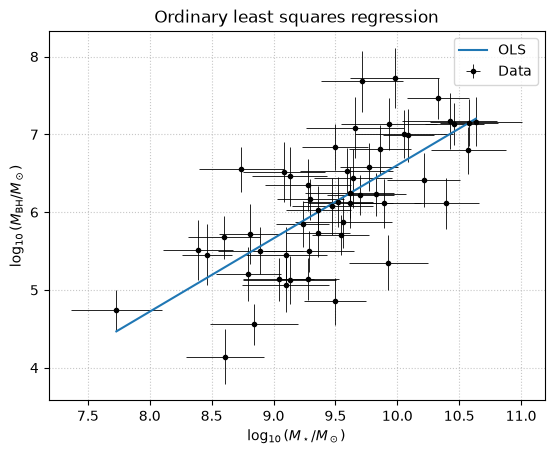

OLS fit values:
alpha = 0.941 +/- 0.132
beta = 6.134 +/- 0.081


In [1]:
# Part 1: your work here
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

def ols(A, y):
    """theta_hat, its covariance (residual-scaled) and the residuals, for design matrix A and data y."""
    AtA_inv = np.linalg.inv(A.T @ A)
    theta = AtA_inv @ A.T @ y
    resid = y - A @ theta
    s2 = resid @ resid / (len(y) - A.shape[1])
    return theta, s2 * AtA_inv, resid

datafile = f'./data/ahuwer2.csv'
data = pd.read_csv(datafile)
#print(data)
logMstar = data['logMstar'].values
err_logMstar = data['err_logMstar']
logMBH = data['logMBH'].values
err_logMBH = data['err_logMBH']

A = np.vstack([np.ones_like(logMstar), logMstar - 9.5]).T
theta, covTheta, resid = ols(A, logMBH)
sig_a = np.sqrt(covTheta[1,1])
sig_b = np.sqrt(covTheta[0,0])

plt.errorbar(logMstar, logMBH, err_logMBH, err_logMstar, 'ko', ms=3, elinewidth=0.6, label='Data')
plt.plot(logMstar, theta[0] + theta[1] * (logMstar - 9.5), label='OLS')
plt.xlabel('$\\log_{10}(M_\\star/M_\\odot)$')
plt.ylabel('$\\log_{10}(M_{\\rm BH}/M_\\odot)$')
plt.title('Ordinary least squares regression')
plt.grid(True, 'both', linestyle=':', alpha=0.7)
plt.legend()
plt.show()

print(f'OLS fit values:')
print(f'alpha = {theta[1]:.3f} +/- {sig_a:.3f}')
print(f'beta = {theta[0]:.3f} +/- {sig_b:.3f}')

**ANSWER (a few sentences):**

$\hat{\alpha}=0.941\pm0.132$ (unitless)

The main assumption of OLS that we're breaking with this dataset is that we have errors which can and will introduce bias into the OLS fit solution. Since we know this data will have x errors, we automatically know that the slope will be biased down on average. This downwards bias is controlled by the relative error, specifically the ratio of $\sigma_x$ to $\sigma_{pop}$. If $\sigma_{x}$ is small relative to $\sigma_{pop}$, then we expect the average ratio of OLS slope to the truth, given by $\sigma_{pop}^2/(\sigma_{pop}^2+\sigma_x^2)$ to be just under 1, and if $\sigma_{x}$ is relatively large compared to $\sigma_{pop}$ that expected ratio should be lower, i.e. more biased.

## Part 2: Estimators you can defend (40%)

Now fit the relation **three more ways** and compare:

1. **Weighted least squares** using the $y$-errors only:
   $\hat{\theta} = (A^{\mathsf T}\Sigma^{-1}A)^{-1}A^{\mathsf T}\Sigma^{-1}y$ with
   $\Sigma = \mathrm{diag}(\sigma_{y,i}^2)$, parameter covariance
   $(A^{\mathsf T}\Sigma^{-1}A)^{-1}$. Does weighting fix the Part 1 bias? Why or why not?

2. **Orthogonal distance regression** (`scipy.odr`, which warns that it is deprecated on
   import; that is fine in the course environment), which knows about the $x$-errors.
   Read what it minimizes before you run it. What does ODR assume about scatter
   *perpendicular to the relation*, and is that assumption true here?

3. **The generative model, honestly.** Write down where each data point comes from:
   the true stellar masses are drawn from the population,
   $x_i^{\rm true} \sim \mathcal{N}(\mu, \sigma_{\rm pop}^2)$; the relation plus intrinsic scatter
   makes the true BH mass; and your measurement errors corrupt both. Marginalizing over
   the (unobservable) true masses makes each observed pair $(x_i, y_i)$ a **bivariate
   Gaussian**:

   $$\begin{pmatrix} x_i \\ y_i \end{pmatrix} \sim \mathcal{N}\!\left[
   \begin{pmatrix} \mu \\ \alpha(\mu - 9.5) + \beta \end{pmatrix},\;
   \begin{pmatrix} \sigma_{\rm pop}^2 + \sigma_{x,i}^2 & \alpha\,\sigma_{\rm pop}^2 \\
   \alpha\,\sigma_{\rm pop}^2 & \alpha^2\sigma_{\rm pop}^2 + \sigma_{\rm int}^2 + \sigma_{y,i}^2 \end{pmatrix}
   \right]$$

   (Convince yourself of the three variance entries before you code; the off-diagonal
   covariance is what removes the attenuation bias. This is the Gaussian core of Kelly 2007, the paper behind
   every modern `linmix`-style fit.) Maximize the summed log-likelihood over all five
   parameters $(\alpha, \beta, \sigma_{\rm int}, \mu, \sigma_{\rm pop})$, and get uncertainties from
   the curvature of the log-likelihood at its peak (the observed information), and say so.

Make **one plot with all four fitted lines overplotted** on your data. They will not agree.
Explain, estimator by estimator, *why* each lands where it does, and which ingredient of the
data each one ignores.

Commit to a **final answer**: one $\alpha \pm \sigma$, $\beta \pm \sigma$, and
$\sigma_{\rm int} \pm \sigma$ you'd put in a paper, and justify the choice. Remember the
3× rule from the header.

C:\Users\Austin\AppData\Local\Temp\ipykernel_32788\2409735792.py:2: DeprecationWarning: `scipy.odr` is deprecated as of version 1.17.0 and will be removed in SciPy 1.19.0. Please use `https://pypi.org/project/odrpack/` instead.
  from scipy import odr


WLS: alpha = 0.943 +/- 0.068, beta = 6.098 +/- 0.043, reduced chi2 = 3.31
ODR: alpha = 1.391 +/- 0.158, beta = 6.098 +/- 0.087, reduced chi2 = 1.49
Generative MLE (errors from curvature of the log-likelihood at its peak):
  alpha     = 1.225 +/- 0.174
  beta      = 6.109 +/- 0.081
  sigma_int = 0.333 +/- 0.103
  mu        = 9.502,  sigma_pop = 0.543 +/- 0.068

method         alpha   sigma   (a - a_gen)/sig_gen
OLS            0.941   0.132                 -1.63
WLS            0.943   0.068                 -1.62
ODR            1.391   0.158                  0.95
Generative     1.225   0.174                  0.00


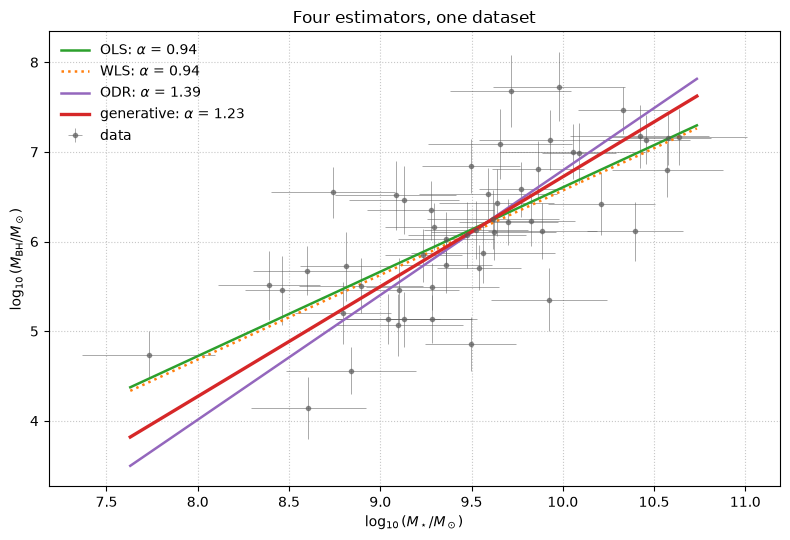

In [2]:
from scipy.optimize import minimize
from scipy import odr
import warnings
warnings.filterwarnings("ignore", category=DeprecationWarning)

# plain arrays
x, y = np.asarray(logMstar, float), np.asarray(logMBH, float)
sx, sy = np.asarray(err_logMstar, float), np.asarray(err_logMBH, float)
N = len(x)

# ---------- 1. WLS (y-errors only) ----------
def gls(A, y, Sigma):
    Si = np.linalg.inv(Sigma)
    cov = np.linalg.inv(A.T @ Si @ A)
    return cov @ A.T @ Si @ y, cov

th_w, cov_w = gls(A, y, np.diag(sy**2))
chi2_w = np.sum(((y - A @ th_w) / sy)**2)
print(f"WLS: alpha = {th_w[1]:.3f} +/- {np.sqrt(cov_w[1,1]):.3f}, "
      f"beta = {th_w[0]:.3f} +/- {np.sqrt(cov_w[0,0]):.3f}, "
      f"reduced chi2 = {chi2_w/(N-2):.2f}")

# ---------- 2. ODR (both error bars, no intrinsic scatter) ----------
def _line(B, xv):
    return B[0] * (xv - 9.5) + B[1]

odr_out = odr.ODR(odr.RealData(x, y, sx=sx, sy=sy), odr.Model(_line),
                  beta0=[th_w[1], th_w[0]]).run()
a_odr, b_odr = odr_out.beta
sa_odr, sb_odr = odr_out.sd_beta
print(f"ODR: alpha = {a_odr:.3f} +/- {sa_odr:.3f}, beta = {b_odr:.3f} +/- {sb_odr:.3f}, "
      f"reduced chi2 = {odr_out.res_var:.2f}")

# ---------- 3. Generative model: bivariate Gaussian per point ----------
# p = [alpha, beta, log sigma_int, mu, log sigma_pop]
def neg2logL_gen(p, x=x, y=y, sx=sx, sy=sy):
    alpha, beta, log_sint, mu, log_sig_pop = p
    sint2, tau2 = np.exp(2*log_sint), np.exp(2*log_sig_pop)
    dx, dy = x - mu, y - (alpha*(mu - 9.5) + beta)
    s11 = tau2 + sx**2
    s22 = alpha**2 * tau2 + sint2 + sy**2
    s12 = alpha * tau2
    det = s11*s22 - s12**2
    quad = (s22*dx**2 - 2*s12*dx*dy + s11*dy**2) / det
    return np.sum(np.log(det) + quad)

def numerical_hessian(f, p, h=1e-4):
    p = np.asarray(p, float); n = p.size; H = np.zeros((n, n))
    for i in range(n):
        for j in range(n):
            ei = np.zeros(n); ej = np.zeros(n); ei[i] = h; ej[j] = h
            H[i, j] = (f(p+ei+ej) - f(p+ei-ej) - f(p-ei+ej) + f(p-ei-ej)) / (4*h*h)
    return H

start = [theta[1], theta[0], np.log(0.3), x.mean(), np.log(x.std())]
res = minimize(neg2logL_gen, start, method='Nelder-Mead',
               options=dict(xatol=1e-8, fatol=1e-10, maxiter=20000))
p_gen = res.x

# observed information: curvature of -2lnL at the peak, cov = 2 * H^-1
cov_gen = 2 * np.linalg.inv(numerical_hessian(neg2logL_gen, p_gen))

alpha_g, sig_alpha_g = p_gen[0], np.sqrt(cov_gen[0, 0])
beta_g,  sig_beta_g  = p_gen[1], np.sqrt(cov_gen[1, 1])
sint_g = np.exp(p_gen[2]);  sig_sint_g = sint_g * np.sqrt(cov_gen[2, 2])   # delta method from log
mu_g = p_gen[3]
spop_g = np.exp(p_gen[4]);  sig_spop_g = spop_g * np.sqrt(cov_gen[4, 4])

print("Generative MLE (errors from curvature of the log-likelihood at its peak):")
print(f"  alpha     = {alpha_g:.3f} +/- {sig_alpha_g:.3f}")
print(f"  beta      = {beta_g:.3f} +/- {sig_beta_g:.3f}")
print(f"  sigma_int = {sint_g:.3f} +/- {sig_sint_g:.3f}")
print(f"  mu        = {mu_g:.3f},  sigma_pop = {spop_g:.3f} +/- {sig_spop_g:.3f}")

# ---------- comparison table ----------
rows = [("OLS", theta[1], sig_a), ("WLS", th_w[1], np.sqrt(cov_w[1,1])),
        ("ODR", a_odr, sa_odr), ("Generative", alpha_g, sig_alpha_g)]
print(f"\n{'method':12s}{'alpha':>8s}{'sigma':>8s}{'(a - a_gen)/sig_gen':>22s}")
for name, a, s in rows:
    print(f"{name:12s}{a:8.3f}{s:8.3f}{(a - alpha_g)/sig_alpha_g:22.2f}")

# ---------- one plot, four lines ----------
xx = np.linspace(x.min() - 0.1, x.max() + 0.1, 100)
fig, ax = plt.subplots(figsize=(8, 5.5))
ax.errorbar(x, y, xerr=sx, yerr=sy, fmt='o', color='0.35', ms=3, elinewidth=0.6, alpha=0.6, label='data')
ax.plot(xx, theta[0] + theta[1]*(xx - 9.5), 'C2', lw=1.8, label=fr'OLS: $\alpha$ = {theta[1]:.2f}')
ax.plot(xx, th_w[0] + th_w[1]*(xx - 9.5), 'C1', lw=1.8, ls=':', label=fr'WLS: $\alpha$ = {th_w[1]:.2f}')
ax.plot(xx, b_odr + a_odr*(xx - 9.5), 'C4', lw=1.8, label=fr'ODR: $\alpha$ = {a_odr:.2f}')
ax.plot(xx, beta_g + alpha_g*(xx - 9.5), 'C3', lw=2.4, label=fr'generative: $\alpha$ = {alpha_g:.2f}')
ax.set_xlabel(r'$\log_{10}(M_\star/M_\odot)$'); ax.set_ylabel(r'$\log_{10}(M_{\rm BH}/M_\odot)$')
ax.set_title('Four estimators, one dataset')
ax.grid(True, ls=':', alpha=0.7); ax.legend(frameon=False)
plt.tight_layout(); plt.show()

**FINAL ANSWER:** $\alpha = $ 1.225 $\pm$ 0.174 (unitless), $\beta = $ 6.109 $\pm$ 0.081 (unitless), $\sigma_{\rm int} = $ 0.333 $\pm$ 0.103 dex

**Justification and uncertainty method (a short paragraph):**

Starting with the comparisons: Weighting doesn't help WLS over OLS very much at all, as the model still does not have any way to account for the inherent bias that you introduce as soon as you add errors to x. Due to this, both WLS and OLS will be biased down in slope about the same amount, which is clearly seen in the plot. Meanwhile, ODR assumes that we don't have any intrinsic scatter $\sigma_{int}$, which is false for this dataset. 

Each data point in the generative model is generated the same way (this explanation is essentially the same as in the review test Q4, so I've reused some of my answer from that): We first draw a latent true mass $x_i^{true}$ from our simulated population with mean $\mu$ and width $\sigma_{pop}$. Then this true mass value is passed along to be used in computing $y_i^{true}$, as well as the observed $x_i^{obs}$. To get the observed mass, we add a normal distribution with variance $\sigma_x^2$ to simulate not having perfect accuracy in our measurements of the mass. Similarly, the $y_i^{true}$ value is drawn from the linear function with slope $\alpha$, intercept $\beta$, and x value $x_i^{true}$, with additional gaussian scatter $\sigma_{int}$ added. We again add a normal distribution to get the observed value $y_i^{obs}$, this time with variance $\sigma_y^2$. Then we simply loop this process N times until we get a dataset of the size we want.

Explanations for each estimator:
* OLS/WLS: both biased similarly low in slope due to the observed quantities having non-zero $\sigma_x$.
* ODR: biased high, as the minimization pushes the denominator of the minimized function high, which includes an $\alpha$ term. This results in somewhat artificially high slopes, just due purely to the way it's computed (though as stated earlier, it also makes an assumption which we've broken with this dataset).
* GLS: much more accurate. As seen in lecture, this method falls between the overestimate of $\alpha$ you get with ODR and the underestimates given by OLS/WLS. This is because the model actually accounts for all of the major values which have an impact on the final observed variables. As a result, this method is what I decided is worth reporting, as I'm much more confident the more robust GLS estimator will report accurate values.

## Part 3: The verification plan, written first and then executed (35%)

**Before you run anything below, write the plan** (3a). A verification plan you invent
after seeing the results is a rationalization.

**3a. The plan.** List the checks you will run to decide whether to trust your Part 2
numbers. At minimum, address:

1. **Closure**: simulate a dataset with a truth *you* choose (the generative recipe in
   Part 2 tells you exactly how) and confirm your fit recovers it.
2. **Bias and efficiency**: Monte Carlo all four estimators on many simulated datasets at
   plausible parameters. Plot each estimator's bias and variance for $\alpha$. This is
   *the* figure of this lab.
3. **Coverage**: across your simulations, do your 68% intervals contain the truth 68% of
   the time, for all three reported parameters?
4. **Sensitivity**: what happens to $\hat\alpha$ if the catalog $x$-errors are wrong by
   ±50% (generate correctly, fit with the mis-stated errors)? If the true population isn't Gaussian (try drawing $x^{\rm true}$ from a uniform
   distribution with the same mean and variance instead)? If you had assumed $\sigma_{\rm int} = 0$?

For **each** check, state *in advance* what failure would look like. A check that cannot
fail is not a check.

**3b. The execution.** Run the plan. Report what each check found, including anything that
failed or surprised you. A failed check honestly reported and diagnosed is worth more than
a wall of green checkmarks.

**VERIFICATION PLAN (write this before running 3b):**

1. Closure: We'll simulate a dataset with $\alpha=1.44$, $\beta=5.90$, $\mu=10.33$, $\sigma_{pop}=0.62$, $\sigma_int=0.27$, and the same $\sigma_x$ and $\sigma_y$ arrays as before. Then we loop over i from 1 to N (same number of points as before), drawing a $x_i^{true}$ value from $\mu,\sigma_{pop}$ and a $y_i^{true}$ value from $\alpha,\beta,\sigma_{int},$ and $x_i^{true}$. Then we scatter on the truth values using a normal distribution and the per-point $\sigma_x,\sigma_y$ values from the sx and sy arrays. Failure in this case would happen if my choice of estimator does not return close to the proper truth values (based on the errors) or the error values from the fit are significantly too large or small.
2. Bias and efficiency: Basically just as it says. Monte Carlo each one of the estimators on many different datasets pulled from the same truth values as in 1, plotting the bias (since we have the truth value) and variance for $\alpha$. Failure here is the same as closure: any estimators with significantly biased fit values or errors which are too large or small indicate a bad estimator for the dataset, and ideally my choice of estimator should perform best.
3. Coverage: Same method as 2; Monte Carlo on those datasets made from the same base truths and manually check with what probability the intervals contain the true value. Failure here is simple, if the $1\sigma$ errors don't contain the truth around 68% of the time, something's gone wrong.
4. Sensitivity: Here we generate a final dataset with the same truths as before (again, we can use the same $\sigma_x$'s from the sx array), but this time after we use the x errors to generate the dataset, we fit with 50% larger and smaller errors to compare. We then also compare by drawing the $x^true_i$ values from a uniform distribution with the same mean and variance. We'll finally compare with a test where we fix $\sigma_int=0$ in our fit after the dataset was already generated with $\sigma_int=0.27\neq0$. There isn't really a failure case here as we are intentionally messing with the estimator, it's more to identify how sensitive the estimator is to such changes.

In [3]:
# ================= Part 3: verification code =================
# Assumes from before: x, y, sx, sy, ols, gls, neg2logL_gen, numerical_hessian, _line, odr, minimize
from scipy.optimize import brentq

SEED = 42
rng = np.random.default_rng(SEED)          # the only source of randomness
TRUTH = dict(alpha=1.44, beta=5.90, sint=0.27, mu=10.33, spop=0.62)
EST = ['ols', 'wls', 'odr', 'gen']
OPT = dict(xatol=1e-7, fatol=1e-9, maxiter=20000)
S_FLOOR, S_MAX = 1e-6, 2.0                 # sigma_int floor (boundary) and profile search ceiling

def simulate(T, sx, sy, uniform_x=False):
    """One dataset from the generative recipe, with per-point sx, sy."""
    n = sx.size
    if uniform_x:      # same mean and variance as the Gaussian
        h = np.sqrt(3) * T['spop']
        xt = rng.uniform(T['mu'] - h, T['mu'] + h, n)
    else:
        xt = rng.normal(T['mu'], T['spop'], n)
    yt = T['alpha']*(xt - 9.5) + T['beta'] + rng.normal(0, T['sint'], n)
    return xt + rng.normal(0, sx), yt + rng.normal(0, sy)

def fit_all(xo, yo, sx_fit, sy, fix_sint0=False):
    """OLS, WLS, ODR and generative fits. sx_fit is the x-error the FIT is told.
    sigma_int interval: Hessian if it works, profile likelihood if sigma_int-hat is at the boundary."""
    A_ = np.vstack([np.ones_like(xo), xo - 9.5]).T
    th_o, cov_o, _ = ols(A_, yo)
    th_w, cov_w = gls(A_, yo, np.diag(sy**2))
    od = odr.ODR(odr.RealData(xo, yo, sx=sx_fit, sy=sy), odr.Model(_line),
                 beta0=[th_w[1], th_w[0]]).run()
    out = dict(a_ols=th_o[1], s_ols=np.sqrt(cov_o[1, 1]),
               a_wls=th_w[1], s_wls=np.sqrt(cov_w[1, 1]),
               a_odr=od.beta[0], s_odr=od.sd_beta[0],
               si_lo=np.nan, si_hi=np.nan, prof=False)

    def hess_sig(f, q):      # sqrt of diag of 2*H^-1 (cov of -2lnL), or NaNs if not positive
        try:
            d = np.diag(2 * np.linalg.inv(numerical_hessian(f, q)))
            if np.all(np.isfinite(d)) and np.all(d > 0):
                return np.sqrt(d)
        except np.linalg.LinAlgError:
            pass
        return np.full(len(q), np.nan)

    if fix_sint0:      # ASSUMED sigma_int = 0: log sigma_int pinned at -30; q = alpha, beta, mu, log sigma_pop
        f = lambda q: neg2logL_gen([q[0], q[1], -30.0, q[2], q[3]], xo, yo, sx_fit, sy)
        r = minimize(f, [th_o[1], th_o[0], xo.mean(), np.log(xo.std())], method='Nelder-Mead', options=OPT)
        sig = hess_sig(f, r.x)
        sp = np.exp(r.x[3])
        return {**out, 'a_gen': r.x[0], 's_gen': sig[0], 'b_gen': r.x[1], 'sb_gen': sig[1], 'si_gen': 0.0,
                'mu_gen': r.x[2], 'smu_gen': sig[2], 'sp_gen': sp, 'ssp_gen': sp * sig[3]}

    f = lambda q: neg2logL_gen(q, xo, yo, sx_fit, sy)      # q = alpha, beta, log sigma_int, mu, log sigma_pop
    r = minimize(f, [th_o[1], th_o[0], np.log(0.3), xo.mean(), np.log(xo.std())],
                 method='Nelder-Mead', options=OPT)
    s_hat, sp = np.exp(r.x[2]), np.exp(r.x[4])
    sig = hess_sig(f, r.x)
    if np.all(np.isfinite(sig)):                       # Hessian works: delta method from the log parameters
        return {**out, 'a_gen': r.x[0], 's_gen': sig[0], 'b_gen': r.x[1], 'sb_gen': sig[1],
                'si_gen': s_hat, 'si_lo': s_hat*(1 - sig[2]), 'si_hi': s_hat*(1 + sig[2]),
                'mu_gen': r.x[3], 'smu_gen': sig[3], 'sp_gen': sp, 'ssp_gen': sp * sig[4]}

    # ---- boundary fit: profile likelihood for sigma_int ----
    ls_hat = np.log(max(s_hat, S_FLOOR))
    q4 = np.delete(r.x, 2)                             # alpha, beta, mu, log sigma_pop
    f4 = lambda q, ls=ls_hat: neg2logL_gen([q[0], q[1], ls, q[2], q[3]], xo, yo, sx_fit, sy)
    sig4 = hess_sig(f4, q4)                            # errors conditional on sigma_int at the boundary
    def g(s):                                          # profile(-2lnL) at sigma_int = s, minus (min + 1)
        return minimize(lambda q: f4(q, np.log(max(s, S_FLOOR))), q4,
                        method='Nelder-Mead', options=OPT).fun - r.fun - 1.0
    hi = S_MAX if g(S_MAX) < 0 else brentq(g, max(s_hat, S_FLOOR), S_MAX, xtol=1e-4)
    lo = 0.0 if g(S_FLOOR) < 0 else brentq(g, S_FLOOR, max(s_hat, 2*S_FLOOR), xtol=1e-4)
    return {**out, 'a_gen': r.x[0], 's_gen': sig4[0], 'b_gen': r.x[1], 'sb_gen': sig4[1],
            'si_gen': s_hat, 'si_lo': lo, 'si_hi': hi, 'prof': True,
            'mu_gen': r.x[3], 'smu_gen': sig4[2], 'sp_gen': sp, 'ssp_gen': sp * sig4[3]}

# ---------------- Check 1: closure (N as in data, then N x25 with tiled errors) ----------------
for tile in (1, 25):
    sxc, syc = np.tile(sx, tile), np.tile(sy, tile)
    F = fit_all(*simulate(TRUTH, sxc, syc), sxc, syc)
    # sigma_int sigma: distance from the fit to the interval end on the truth's side
    s_si = (F['si_hi'] - F['si_gen']) if TRUTH['sint'] > F['si_gen'] else (F['si_gen'] - F['si_lo'])
    print(f"\nClosure, N = {sxc.size}\n")
    print(f"{'param':8s}{'truth':>8s}{'fit':>8s}{'sigma':>8s}{'z':>7s}")
    for nm, tv, v, s in [('alpha', TRUTH['alpha'], F['a_gen'], F['s_gen']),
                         ('beta', TRUTH['beta'], F['b_gen'], F['sb_gen']),
                         ('sig_int', TRUTH['sint'], F['si_gen'], s_si),
                         ('mu', TRUTH['mu'], F['mu_gen'], F['smu_gen']),
                         ('sig_pop', TRUTH['spop'], F['sp_gen'], F['ssp_gen'])]:
        print(f"{nm:8s}{tv:8.3f}{v:8.3f}{s:8.3f}{(v - tv)/s:7.2f}")

# ---------------- Ensembles: each dataset generated once, refit under every config ----------------
def run_ensemble(configs, n=500, uniform_x=False):
    out = {c: [] for c in configs}
    for _ in range(n):
        xo, yo = simulate(TRUTH, sx, sy, uniform_x)
        for c, (scale, fix0) in configs.items():
            out[c].append(fit_all(xo, yo, sx*scale, sy, fix0))
    return {c: {k: np.array([r[k] for r in rs]) for k in rs[0]} for c, rs in out.items()}

def summarize(R, title):
    T = TRUTH; ok = np.isfinite(R['s_gen'])
    print(f"\n{title} ({ok.sum()}/{ok.size} fits with finite errors)\n")

    print(f"{'alpha':8s}{'bias':>9s}{'std':>8s}{'cov68':>8s}")
    for e in EST:
        a, s = R[f'a_{e}'][ok], R[f's_{e}'][ok]
        print(f"{e:8s}{a.mean() - T['alpha']:+9.3f}{a.std(ddof=1):8.3f}{100*np.mean(np.abs(a - T['alpha']) < s):7.0f}%")

    rows = [('beta',    R['b_gen'],  np.abs(R['b_gen'] - T['beta']) < R['sb_gen'],    T['beta']),
            ('mu',      R['mu_gen'], np.abs(R['mu_gen'] - T['mu']) < R['smu_gen'],    T['mu']),
            ('sig_pop', R['sp_gen'], np.abs(R['sp_gen'] - T['spop']) < R['ssp_gen'],  T['spop'])]
    if not np.all(np.isnan(R['si_lo'])):               # skipped when sigma_int is assumed 0
        rows.append(('sig_int', R['si_gen'], (R['si_lo'] <= T['sint']) & (T['sint'] <= R['si_hi']), T['sint']))
    print(f"\n{'gen':8s}{'bias':>9s}{'std':>8s}{'cov68':>8s}")
    for nm, v, hit, tv in rows:
        print(f"{nm:8s}{v[ok].mean() - tv:+9.3f}{v[ok].std(ddof=1):8.3f}{100*hit[ok].mean():7.0f}%")

# configs: name -> (scale applied to sx given to the fit, ASSUME sigma_int = 0?)
R = run_ensemble({'base': (1.0, False), 'sx x0.5': (0.5, False),
                  'sx x1.5': (1.5, False), 'fit sint=0': (1.0, True)}, n=500)
R_uni = run_ensemble({'base': (1.0, False)}, n=500, uniform_x=True)


Closure, N = 53

param      truth     fit   sigma      z
alpha      1.440   1.522   0.182   0.45
beta       5.900   5.824   0.175  -0.43
sig_int    0.270   0.000   0.189  -1.43
mu        10.330  10.348   0.074   0.25
sig_pop    0.620   0.447   0.062  -2.80

Closure, N = 1325

param      truth     fit   sigma      z
alpha      1.440   1.449   0.030   0.31
beta       5.900   5.876   0.030  -0.82
sig_int    0.270   0.267   0.025  -0.11
mu        10.330  10.319   0.019  -0.56
sig_pop    0.620   0.624   0.015   0.25


In [4]:
summarize(R['base'], "Checks 2-3: Gaussian x_true, correct errors")


Checks 2-3: Gaussian x_true, correct errors (500/500 fits with finite errors)

alpha        bias     std   cov68
ols        -0.287   0.112      8%
wls        -0.284   0.111      2%
odr        +0.103   0.160     54%
gen        +0.016   0.154     69%

gen          bias     std   cov68
beta       -0.012   0.149     70%
mu         -0.006   0.091     68%
sig_pop    -0.014   0.073     67%
sig_int    -0.047   0.141     68%


In [5]:
summarize(R['sx x0.5'], "Check 4a: fit with x-errors x0.5")
summarize(R['sx x1.5'], "Check 4a: fit with x-errors x1.5")


Check 4a: fit with x-errors x0.5 (500/500 fits with finite errors)

alpha        bias     std   cov68
ols        -0.287   0.112      8%
wls        -0.284   0.111      2%
odr        -0.112   0.132     47%
gen        -0.216   0.119     24%

gen          bias     std   cov68
beta       +0.179   0.122     34%
mu         -0.005   0.091     68%
sig_pop    +0.040   0.068     61%
sig_int    +0.155   0.075     11%

Check 4a: fit with x-errors x1.5 (500/500 fits with finite errors)

alpha        bias     std   cov68
ols        -0.287   0.112      8%
wls        -0.284   0.111      2%
odr        +0.212   0.176     38%
gen        +0.211   0.176     49%

gen          bias     std   cov68
beta       -0.172   0.168     59%
mu         -0.006   0.092     70%
sig_pop    -0.059   0.076     60%
sig_int    -0.265   0.029     10%



Check 4b: uniform x_true (500/500 fits with finite errors)

alpha        bias     std   cov68
ols        -0.279   0.118     11%
wls        -0.276   0.118      3%
odr        +0.098   0.160     60%
gen        +0.017   0.160     66%

gen          bias     std   cov68
beta       -0.010   0.158     67%
mu         -0.003   0.088     73%
sig_pop    -0.009   0.059     78%
sig_int    -0.052   0.135     74%

Check 4c: fit assuming sigma_int = 0 (500/500 fits with finite errors)

alpha        bias     std   cov68
ols        -0.287   0.112      8%
wls        -0.284   0.111      2%
odr        +0.103   0.160     54%
gen        +0.103   0.160     52%

gen          bias     std   cov68
beta       -0.084   0.155     59%
mu         -0.005   0.091     67%
sig_pop    -0.025   0.074     63%

coverage of 0.68 is uncertain by +/- 0.021 at n = 500 fits


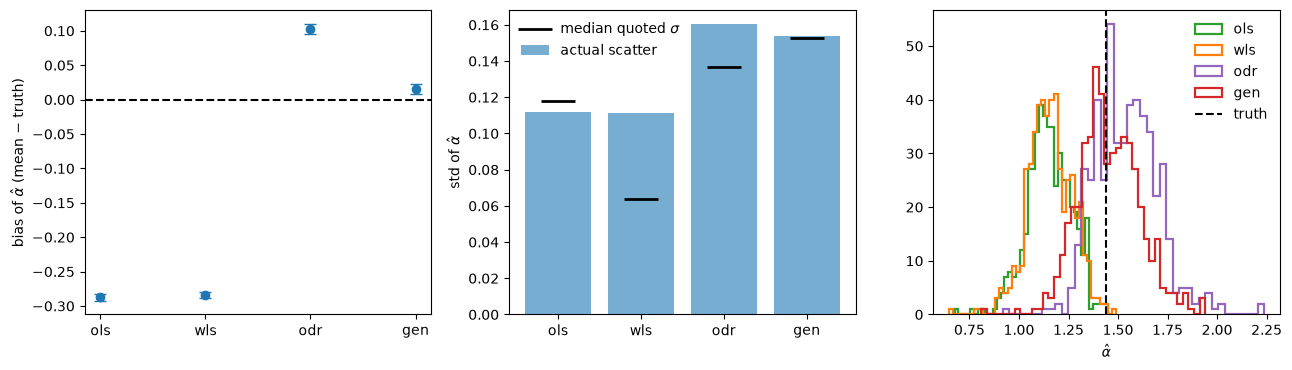

In [6]:
summarize(R_uni['base'], "Check 4b: uniform x_true")
summarize(R['fit sint=0'], "Check 4c: fit assuming sigma_int = 0")

n = np.isfinite(R['base']['s_gen']).sum()
print(f"\ncoverage of 0.68 is uncertain by +/- {np.sqrt(0.68*0.32/n):.3f} at n = {n} fits")

# ---------------- Bias / variance figure (check 2) ----------------
B = R['base']; ok = np.isfinite(B['s_gen']); n = ok.sum()
a = [B[f'a_{e}'][ok] for e in EST]
fig, ax = plt.subplots(1, 3, figsize=(13, 3.8))
ax[0].errorbar(range(4), [v.mean() - TRUTH['alpha'] for v in a],
               yerr=[v.std(ddof=1)/np.sqrt(n) for v in a], fmt='o', capsize=4)
ax[0].axhline(0, color='k', ls='--'); ax[0].set_ylabel(r'bias of $\hat\alpha$ (mean $-$ truth)')
ax[1].bar(range(4), [v.std(ddof=1) for v in a], alpha=0.6, label='actual scatter')
ax[1].plot(range(4), [np.median(B[f's_{e}'][ok]) for e in EST], 'k_', ms=25, mew=2,
           label=r'median quoted $\sigma$')
ax[1].set_ylabel(r'std of $\hat\alpha$'); ax[1].legend(frameon=False)
for i in (0, 1):
    ax[i].set_xticks(range(4)); ax[i].set_xticklabels(EST)
for v, e, c in zip(a, EST, ['C2', 'C1', 'C4', 'C3']):
    ax[2].hist(v, 40, histtype='step', lw=1.6, color=c, label=e)
ax[2].axvline(TRUTH['alpha'], color='k', ls='--', label='truth'); ax[2].legend(frameon=False)
ax[2].set_xlabel(r'$\hat\alpha$')
plt.tight_layout(); plt.show()

**WHAT THE CHECKS FOUND:**

1. Closure: all fitted values fall within $1\sigma$ at high enough N, indicating that the generative least squares estimator is able to properly obtain the correct results from a simulated dataset. No failures observed.
2. Bias and efficiency: As stated in my expectations and analysis earlier in this doc, we see that OLS and WLS are biased negatively in $\alpha$, while ODR is biased positive and GLS is still biased, but significantly less than all the other estimators. Everything is reasonable here and we don't see any failures.
3. Coverage: Again as expected, the OLS and WLS fits behave poorly in coverage, vastly underestimating the actual error on $\alpha$. ODR is better but still not close to the expected 68%. GLS meanwhile has all its fitted parameters within the 67-70% range, indicating that the $1\sigma$ errors are, in fact, proper $1\sigma$ errors and thus we don't have any failures here.
4. Sensitivity: Not really any failures that could be noted, but I'll briefly mention some notable effects. 50% decreased assumed x errors results in generally larger biases and smaller quoted errors, so besides the $\mu$ mean all other values fell outside the ideal coverage range. Similarly, larger assumed x errors yield generally larger biases and lower coverages on everything but $\mu$. These two cases seem to particularly impact $\sigma_{int}$'s accuracy. Uniform true xs hurt the other estimators much more than GLS, but still significantly impacted coverages, particularly for $\beta,\sigma_{int},\sigma_{pop}$, though biases stayed very low for GLS. Assuming $\sigma_{int}=0$ did not affect the other estimators at all, as expected since they don't account for it. It did however significantly increase biases of $\alpha$ and $\beta$ for GLS while lowering coverage for all fitted variables but $\mu$.

## Part 4: AI-use appendix (10%)

**AI use**: which tools did you use (Copilot, Claude, ChatGPT, none, ...), for what,
what did they get wrong, and how did you catch it? Honesty is graded; "I didn't use any"
is fine if true.

**AI-USE APPENDIX:**

Part 1: No AI was used.

Part 2: Claude was used to generate the main code, based on specifications I provided. It did not get anything numerically wrong initially, but I did rerun with a better formulated prompt after the first attempt to clarify how I wanted it to compute things like the errors from with the Hessian, as well as to simplify the code.

Part 3: Claude was again used to generate the code based on my exact verification plan (I simply pasted the plan and told it to implement what I had written). Claude did make an error here, albeit somewhat small. The code at first only ignored any cases where the curvature errors ended up being NaNs, so it threw out data and specifically messed up the coverage percentages for $\sigma_{int}$. I had it implement the fix suggested at the top of this document, profile-likelihood width, on only the cases where the error could not be computed with the Hessian. The only other issue was that Claude made it significantly longer and more complicated than required, for example defining several functions that were only ever used once and completely over-bloating the analysis print statements. The current prints are already long enough to need to overflow into extra code blocks, but I feel they do add some helpful information so I kept the current level; I just had to force Claude to debloat and remove a ton of extra information which only made the important info harder to parse.

Part 4: No AI was used (of course).